# FDConv vs WDConv — Object Detection on PASCAL VOC 2007

**BLM5103 Computer Vision Project**

Comparing three Faster R-CNN (ResNet-50 + FPN) variants:

| Variant | Description | Batch Size | LR |
|---------|-------------|-----------|-----|
| Baseline | Standard Conv2d | 8 | 0.02 |
| FDConv | Fourier Dynamic Convolution (CVPR 2025) | 4 | 0.005 |
| WDConv | Wavelet Dynamic Convolution (Haar DWT) | 4 | 0.005 |

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ===================== Cell 0: Setup & Installation =====================

# Clone FDConv repo (for FDConv.py only)
!git clone https://github.com/Linwei-Chen/FDConv.git FDConv_repo 2>/dev/null || echo 'Already cloned'

# Install dependencies (no mmcv, no mmdetection)
!pip install -q torchvision torchmetrics pycocotools timm tqdm matplotlib pandas numpy

# Verify GPU
import torch
print(f'GPU: {torch.cuda.get_device_name()}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'PyTorch: {torch.__version__}')
print(f'Python: {__import__("sys").version}')

import warnings
warnings.filterwarnings('ignore')



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 20.6 MB/s eta 0:00:00
GPU: Tesla T4
VRAM: 15.6 GB
PyTorch: 2.10.0+cu128
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [ ]:
# ===================== Cell 1: Imports =====================

import sys, os, json, time
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from torch.utils.data import DataLoader

sys.path.insert(0, '/content/FDConv_repo/FDConv_detection/mmdet_custom')

from voc_dataset import VOCDetectionDataset, collate_fn, VOC_CLASSES
from models import build_model
from engine import train_variant, save_json, load_json, seed_everything
from metrics import evaluate, benchmark_fps

print('All imports OK')

All imports OK


In [ ]:
# ===================== Cell 2: Configuration =====================

# ----- CHANGE THESE PATHS -----
DATA_ROOT  = '/content/drive/MyDrive/DATASETS/PASCAL_VOC_2007/PASCAL_VOC_2007' # where VOC will be downloaded
OUTPUT_DIR = '/content/drive/MyDrive/FDConv_Detection/runs'    # save results to Drive
# ------------------------------

NUM_CLASSES  = 21          # 20 VOC classes + background
KERNEL_NUM   = 64          # basis kernels for FDConv/WDConv
NUM_EPOCHS   = 12          # standard 1x schedule
NUM_WORKERS  = 2
SEED         = 42
MAX_NORM     = 5.0         # gradient clipping (mandatory for FDConv/WDConv)
PRETRAINED   = True        # ImageNet pretrained backbone (CRITICAL for 12-epoch VOC)
# Per-variant settings
VARIANT_BS  = {'Baseline': 8, 'FDConv': 4, 'WDConv': 4}
VARIANT_LR  = {'Baseline': 0.02, 'FDConv': 0.005, 'WDConv': 0.005}
# AMP: bfloat16 is safer for FDConv/WDConv (same exponent range as fp32, no overflow)
VARIANT_AMP = {'Baseline': True, 'FDConv': True, 'WDConv': True}
VARIANTS = ['Baseline', 'FDConv', 'WDConv']
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Output: {OUTPUT_DIR}')

Device: cuda
Output: /content/drive/MyDrive/FDConv_Detection/runs


In [ ]:
# ===================== Cell 3: Download VOC 2007 =====================

from torchvision.datasets import VOCDetection

print('Downloading VOC 2007 trainval...')
_ = VOCDetection(DATA_ROOT, year='2007', image_set='trainval', download=False)
print('Downloading VOC 2007 test...')
_ = VOCDetection(DATA_ROOT, year='2007', image_set='test', download=False)
print('Done.')

Done.


In [ ]:
# ===================== Cell 4: Build Datasets =====================

train_dataset = VOCDetectionDataset(DATA_ROOT, split='trainval', augment=True)
test_dataset  = VOCDetectionDataset(DATA_ROOT, split='test',     augment=False)

print(f'Train: {len(train_dataset)} images')
print(f'Test:  {len(test_dataset)} images')

# Quick sanity: check one sample
img, tgt = train_dataset[0]
print(f'Image shape: {img.shape}')
print(f'Boxes: {tgt["boxes"].shape}, Labels: {tgt["labels"]}')

Train: 5011 images
Test:  4952 images
Image shape: torch.Size([3, 375, 500])
Boxes: torch.Size([5, 4]), Labels: tensor([9, 9, 9, 9, 9])


In [ ]:
# Remove mmcv dependency from FDConv.py
!sed -i 's/from mmcv.cnn import CONV_LAYERS/# from mmcv.cnn import CONV_LAYERS/g' /content/FDConv_repo/FDConv_detection/mmdet_custom/FDConv.py
!sed -i 's/@CONV_LAYERS.register_module()/# @CONV_LAYERS.register_module()/g' /content/FDConv_repo/FDConv_detection/mmdet_custom/FDConv.py

print('Patched FDConv.py to remove mmcv dependency.')

Patched FDConv.py to remove mmcv dependency.


In [ ]:
# ===================== Cell 5: Build Models =====================

seed_everything(SEED)

all_models = {}
replacement_logs = {}
for name in VARIANTS:
    print(f'\nBuilding {name}...')
    model, log = build_model(NUM_CLASSES, variant=name, kernel_num=KERNEL_NUM,
                             pretrained=PRETRAINED)
    all_models[name] = model
    replacement_logs[name] = log
    n_params = sum(p.numel() for p in model.parameters())
    n_full = len([e for e in log if e[4] == 'full'])
    n_pass = len([e for e in log if e[4] == 'pass-through'])
    print(f'  {name}: {n_params/1e6:.2f}M params, '
          f'{n_full} full dynamic layers, {n_pass} pass-through')

# Save model info
for name in VARIANTS:
    info = {
        'variant': name,
        'params_M': round(sum(p.numel() for p in all_models[name].parameters()) / 1e6, 2),
        'full_dynamic_layers': len([e for e in replacement_logs[name] if e[4] == 'full']),
        'replaced_layers': [(e[0], e[1], e[2], e[3], e[4]) for e in replacement_logs[name]],
    }
    save_json(info, os.path.join(OUTPUT_DIR, name, 'model_info.json'))



Building Baseline...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 170MB/s]


  Baseline: 41.40M params, 0 full dynamic layers, 0 pass-through

Building FDConv...
  FDConv: 45.44M params, 52 full dynamic layers, 0 pass-through

Building WDConv...
  WDConv: 45.37M params, 52 full dynamic layers, 0 pass-through


In [ ]:
# ===================== Cell 6: Sanity Check =====================

# Test one forward pass for all variants
tmp_loader = DataLoader(train_dataset, batch_size=2, shuffle=False,
                        num_workers=0, collate_fn=collate_fn)
images, targets = next(iter(tmp_loader))

for name, model in all_models.items():
    model.to(device).train()
    imgs = [img.to(device) for img in images]
    tgts = [{k: v.to(device) for k, v in t.items()} for t in targets]
    with torch.cuda.amp.autocast(dtype=torch.bfloat16):
        losses = model(imgs, tgts)
    total = sum(losses.values())
    print(f'{name}: loss={total.item():.3f}  keys={list(losses.keys())}')
    vram = torch.cuda.max_memory_allocated() / 1e9
    print(f'  VRAM: {vram:.2f} GB (bs=2)')
    model.cpu()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.empty_cache()

print('\nSanity check passed!')
del tmp_loader

Baseline: loss=3.892  keys=['loss_classifier', 'loss_box_reg', 'loss_objectness', 'loss_rpn_box_reg']
  VRAM: 3.53 GB (bs=2)
FDConv: loss=3.841  keys=['loss_classifier', 'loss_box_reg', 'loss_objectness', 'loss_rpn_box_reg']
  VRAM: 8.79 GB (bs=2)
WDConv: loss=3.714  keys=['loss_classifier', 'loss_box_reg', 'loss_objectness', 'loss_rpn_box_reg']
  VRAM: 11.33 GB (bs=2)

Sanity check passed!


In [ ]:
# ===================== Cell 7: Training Loop =====================

all_metrics = {}
variant_times = {}

for variant_name in VARIANTS:
    print(f'\n{"="*60}\n  TRAINING: {variant_name}\n{"="*60}')
    t_start = time.time()

    bs = VARIANT_BS[variant_name]
    lr = VARIANT_LR[variant_name]
    use_amp = VARIANT_AMP[variant_name]

    train_loader = DataLoader(
        train_dataset, batch_size=bs, shuffle=True,
        num_workers=NUM_WORKERS, collate_fn=collate_fn, drop_last=True,
        pin_memory=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    test_loader = DataLoader(
        test_dataset, batch_size=bs, shuffle=False,
        num_workers=NUM_WORKERS, collate_fn=collate_fn,
        pin_memory=True,
    )

    # Save config
    save_json({'variant': variant_name, 'lr': lr, 'batch_size': bs,
               'num_epochs': NUM_EPOCHS, 'kernel_num': KERNEL_NUM,
               'max_norm': MAX_NORM, 'seed': SEED, 'use_amp': use_amp,
               'pretrained': PRETRAINED},
              os.path.join(OUTPUT_DIR, variant_name, 'config.json'))

    seed_everything(SEED)
    metrics = train_variant(
        name=variant_name,
        model=all_models[variant_name],
        train_loader=train_loader,
        test_loader=test_loader,
        device=device,
        output_dir=OUTPUT_DIR,
        lr=lr,
        num_epochs=NUM_EPOCHS,
        max_norm=MAX_NORM,
        use_amp=use_amp,
    )
    all_metrics[variant_name] = metrics

    elapsed = (time.time() - t_start) / 60
    variant_times[variant_name] = round(elapsed, 2)
    print(f'  Wall-clock: {elapsed:.1f} min')
    all_models[variant_name].cpu()
    torch.cuda.empty_cache()

save_json(variant_times, os.path.join(OUTPUT_DIR, 'variant_times.json'))
print('\nAll training complete!')



  TRAINING: Baseline
  Resuming from /content/drive/MyDrive/FDConv_Detection/runs/Baseline/last.pth
  Wall-clock: 0.2 min

  TRAINING: FDConv
  Resuming from /content/drive/MyDrive/FDConv_Detection/runs/FDConv/last.pth
  Wall-clock: 0.1 min

  TRAINING: WDConv
  Resuming from /content/drive/MyDrive/FDConv_Detection/runs/WDConv/last.pth
  Wall-clock: 0.1 min

All training complete!


In [ ]:
# ===================== Cell 8: Load Results (Resume Support) =====================

# Reload metrics from disk (useful after Colab disconnect)
all_metrics = {}
all_losses = {}
for name in VARIANTS:
    metrics_path = os.path.join(OUTPUT_DIR, name, 'metrics.json')
    losses_path = os.path.join(OUTPUT_DIR, name, 'losses.json')
    if os.path.exists(metrics_path):
        all_metrics[name] = load_json(metrics_path)
        print(f'{name}: {len(all_metrics[name])} epochs loaded')
        last = all_metrics[name][-1]
        print(f'  Last: mAP@50={last["val_mAP_50"]:.4f}  loss={last["train_loss"]:.4f}')
    if os.path.exists(losses_path):
        all_losses[name] = load_json(losses_path)

if os.path.exists(os.path.join(OUTPUT_DIR, 'variant_times.json')):
    variant_times = load_json(os.path.join(OUTPUT_DIR, 'variant_times.json'))
    print(f'\nVariant times: {variant_times}')

Baseline: 12 epochs loaded
  Last: mAP@50=0.6736  loss=0.2533
FDConv: 12 epochs loaded
  Last: mAP@50=0.3829  loss=0.3181
WDConv: 12 epochs loaded
  Last: mAP@50=0.3699  loss=0.3310

Variant times: {'Baseline': 0.18, 'FDConv': 0.12, 'WDConv': 0.11}


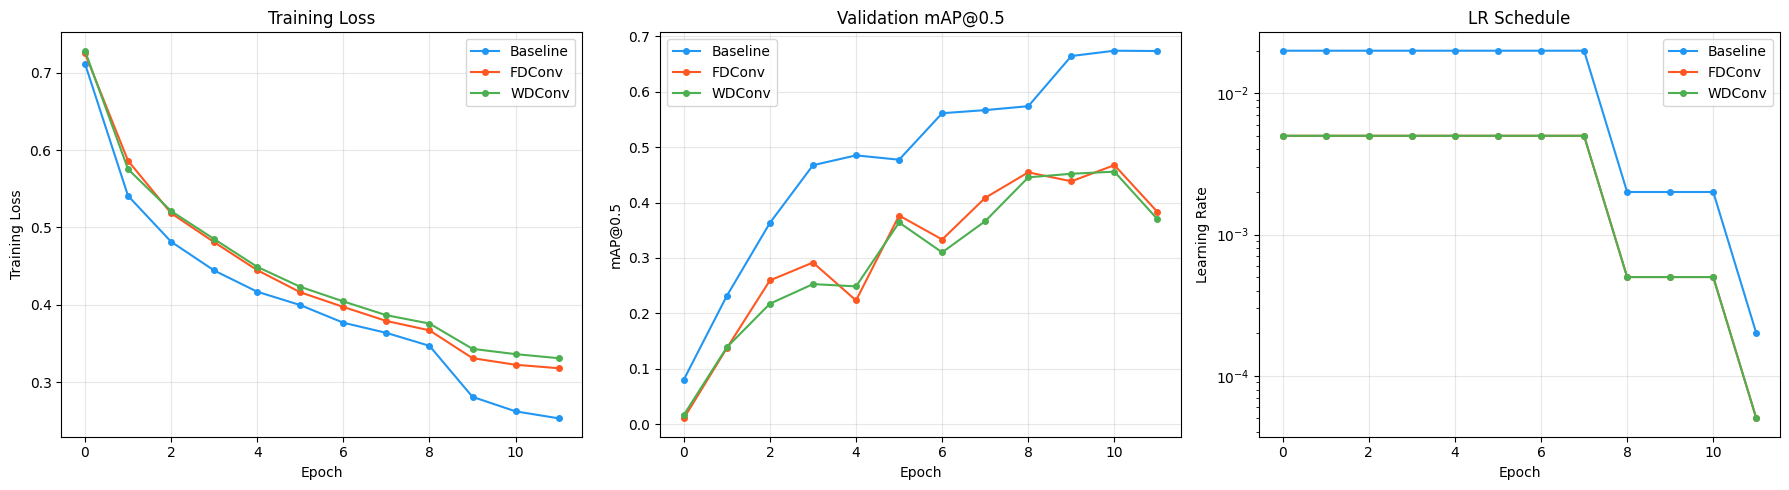

In [ ]:
# ===================== Cell 9: Training Curves =====================

colors = {'Baseline': '#2196F3', 'FDConv': '#FF5722', 'WDConv': '#4CAF50'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Training loss per epoch
ax = axes[0]
for name in VARIANTS:
    if name not in all_metrics:
        continue
    epochs = [m['epoch'] for m in all_metrics[name]]
    losses = [m['train_loss'] for m in all_metrics[name]]
    ax.plot(epochs, losses, '-o', label=name, color=colors[name], markersize=4)
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title('Training Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# (b) mAP@50 per epoch
ax = axes[1]
for name in VARIANTS:
    if name not in all_metrics:
        continue
    epochs = [m['epoch'] for m in all_metrics[name]]
    maps = [m['val_mAP_50'] for m in all_metrics[name]]
    ax.plot(epochs, maps, '-o', label=name, color=colors[name], markersize=4)
ax.set_xlabel('Epoch')
ax.set_ylabel('mAP@0.5')
ax.set_title('Validation mAP@0.5')
ax.legend()
ax.grid(True, alpha=0.3)

# (c) LR schedule
ax = axes[2]
for name in VARIANTS:
    if name not in all_metrics:
        continue
    epochs = [m['epoch'] for m in all_metrics[name]]
    lrs = [m['lr'] for m in all_metrics[name]]
    ax.plot(epochs, lrs, '-o', label=name, color=colors[name], markersize=4)
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_title('LR Schedule')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ===================== Cell 10: Summary Table =====================

rows = []
for name in VARIANTS:
    if name not in all_metrics:
        continue
    info_path = os.path.join(OUTPUT_DIR, name, 'model_info.json')
    info = load_json(info_path) if os.path.exists(info_path) else {}
    best = max(all_metrics[name], key=lambda m: m.get('val_mAP_50', 0))
    total_time = all_metrics[name][-1].get('cumulative_time_sec', 0)
    rows.append({
        'Variant': name,
        'Params (M)': info.get('params_M', '?'),
        'mAP@0.5': f'{best["val_mAP_50"]:.4f}',
        'mAP@0.75': f'{best.get("val_mAP_75", 0):.4f}',
        'mAP': f'{best.get("val_mAP", 0):.4f}',
        'Best Epoch': best['epoch'],
        'Train Time (h)': f'{total_time/3600:.1f}',
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))
df.to_csv(os.path.join(OUTPUT_DIR, 'summary.csv'), index=False)

 Variant  Params (M) mAP@0.5 mAP@0.75    mAP  Best Epoch Train Time (h)
Baseline       41.40  0.6741   0.3393 0.3590          10            1.3
  FDConv       45.44  0.4675   0.2098 0.2358          10            3.2
  WDConv       45.37  0.4557   0.1872 0.2209          10            3.7


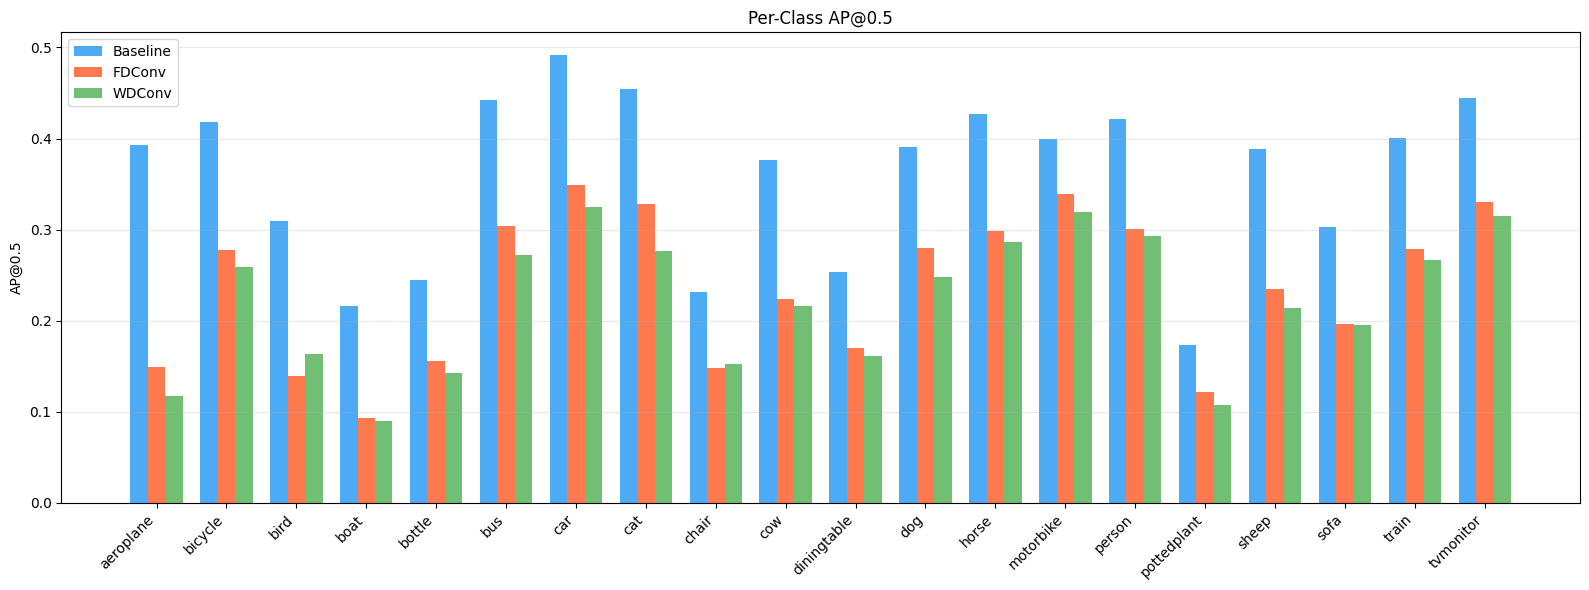

In [ ]:
# ===================== Cell 11: Per-Class AP Bar Chart =====================

class_names = VOC_CLASSES[1:]  # exclude __background__

fig, ax = plt.subplots(figsize=(16, 6))
x = np.arange(len(class_names))
width = 0.25

for i, name in enumerate(VARIANTS):
    if name not in all_metrics:
        continue
    best = max(all_metrics[name], key=lambda m: m.get('val_mAP_50', 0))
    per_class = best.get('per_class_ap50', [0]*20)
    if len(per_class) < 20:
        per_class = per_class + [0] * (20 - len(per_class))
    ax.bar(x + i*width, per_class[:20], width, label=name, color=colors[name], alpha=0.8)

ax.set_xticks(x + width)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_ylabel('AP@0.5')
ax.set_title('Per-Class AP@0.5')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'per_class_ap.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ===================== Cell 12: Speed Benchmark & VRAM =====================

speed_results = {}
for name in VARIANTS:
    print(f'\nBenchmarking {name}...')
    model = all_models[name].to(device)
    model.eval()

    # VRAM measurement (one forward pass at full batch size)
    torch.cuda.reset_peak_memory_stats()
    bs = VARIANT_BS[name]
    tmp_loader = DataLoader(test_dataset, batch_size=bs, shuffle=False,
                            num_workers=0, collate_fn=collate_fn)
    imgs, _ = next(iter(tmp_loader))
    with torch.inference_mode():
        _ = model([img.to(device) for img in imgs])
    vram_gb = torch.cuda.max_memory_allocated() / 1e9

    # FPS
    fps = benchmark_fps(model, device, warmup=10, runs=50)

    speed_results[name] = {'fps': round(fps, 1), 'vram_gb': round(vram_gb, 2)}
    print(f'  {name}: {fps:.1f} FPS, {vram_gb:.2f} GB VRAM')

    model.cpu()
    torch.cuda.empty_cache()

save_json(speed_results, os.path.join(OUTPUT_DIR, 'speed_results.json'))
del tmp_loader

# Display table
speed_df = pd.DataFrame(speed_results).T
print('\n', speed_df.to_string())


Benchmarking Baseline...
  Baseline: 7.8 FPS, 10.60 GB VRAM

Benchmarking FDConv...
  FDConv: 4.8 FPS, 8.00 GB VRAM

Benchmarking WDConv...
  WDConv: 4.4 FPS, 8.18 GB VRAM

           fps  vram_gb
Baseline  7.8    10.60
FDConv    4.8     8.00
WDConv    4.4     8.18


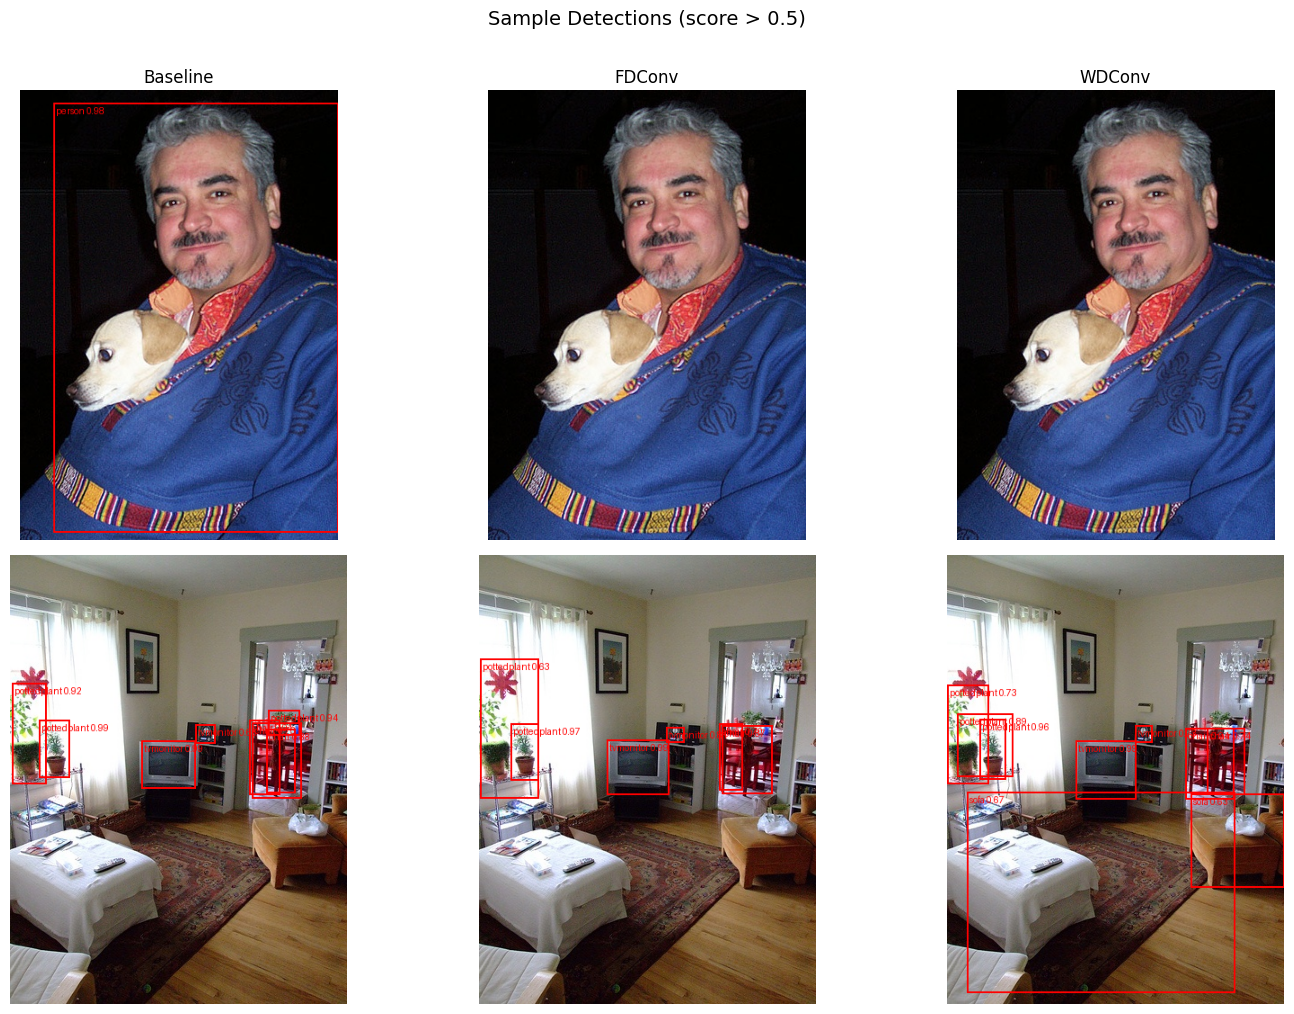

In [ ]:
import torchvision.transforms.functional as F_tv
from torchvision.utils import draw_bounding_boxes

# Pick 4 test images
sample_indices = [0, 200]
n_samples = len(sample_indices)

# Change subplot layout to n_samples rows, len(VARIANTS) columns
fig, axes = plt.subplots(n_samples, len(VARIANTS), figsize=(5 * len(VARIANTS), 5 * n_samples))
# Ensure axes is always a 2D array for consistent indexing
if n_samples == 1 and len(VARIANTS) == 1:
    axes = np.array([[axes]])
elif n_samples == 1 or len(VARIANTS) == 1:
    axes = np.atleast_2d(axes)

for row_idx, idx in enumerate(sample_indices):
    for col_idx, name in enumerate(VARIANTS):
        model = all_models[name].to(device)
        model.eval()

        img, _ = test_dataset[idx]
        with torch.inference_mode():
            pred = model([img.to(device)])[0]

        # Filter low-confidence detections
        keep = pred['scores'] > 0.6
        boxes = pred['boxes'][keep].cpu()
        labels = pred['labels'][keep].cpu()
        scores = pred['scores'][keep].cpu()

        label_strs = [f'{VOC_CLASSES[l.item()]} {s:.2f}'
                      for l, s in zip(labels, scores)]

        img_uint8 = (img * 255).to(torch.uint8)
        if len(boxes) > 0:
            img_drawn = draw_bounding_boxes(img_uint8, boxes, label_strs,
                                            colors='red', width=2, font_size=12)
        else:
            img_drawn = img_uint8

        ax = axes[row_idx, col_idx]
        ax.imshow(img_drawn.permute(1, 2, 0).numpy())

        # Set titles for columns (variant names) and row labels (image indices)
        if row_idx == 0:
            ax.set_title(f'{name}', fontsize=12)
        if col_idx == 0:
            ax.set_ylabel(f'Image {idx}', rotation=0, ha='right', fontsize=12)
        ax.axis('off')

    model.cpu()
    torch.cuda.empty_cache()

plt.suptitle('Sample Detections (score > 0.5)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sample_detections.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ===================== Cell 14: Download Results =====================

import shutil

zip_path = shutil.make_archive('/content/fdconv_detection_results', 'zip', OUTPUT_DIR)
print(f'Results archived to: {zip_path}')
print(f'Size: {os.path.getsize(zip_path) / 1e6:.1f} MB')

# For Colab download
try:
    from google.colab import files
    files.download(zip_path)
except ImportError:
    print('Not in Colab, skipping download')

Results archived to: /content/fdconv_detection_results.zip
Size: 1973.6 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>